# Tracking Political Change with Embeddings of Parliamentary Speeches
### 0. Imports & Paths
The following datasets were collected to analyse our research question
- Open Discourse Bundestag Dataset (covering 1949-2021)
- Chapel Expert Survey
- Manifesto Project

In [1]:
# Imports and Paths
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")

### 1. Load the raw data

In [2]:
speeches  = pd.read_csv(RAW / "speeches.csv")
ches      = pd.read_csv(RAW / "CHES.csv")
manifesto = pd.read_csv(RAW / "manifesto.csv")

# Auxiliary Open Discourse table
factions  = pd.read_csv(RAW / "factions.csv")

print("speeches: ", speeches.shape)
print("ches:     ", ches.shape)
print("manifesto:", manifesto.shape)
print("factions: ", factions.shape)

speeches:  (907644, 12)
ches:      (1441, 90)
manifesto: (5285, 175)
factions:  (28, 3)


/var/folders/s5/fy91nyld24n09t7z3kdvvvzh0000gn/T/ipykernel_69101/3045564478.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  manifesto = pd.read_csv(RAW / "manifesto.csv")


### 2. Preprocessing

*Possible decision*: Only look at speeches between 2010 and 2021 and filter out guest speakers

In [3]:
# Turn dates into real dates
speeches["date"] = pd.to_datetime(speeches["date"], errors="coerce")

# Keep only speeches from 2010 up to the end of the data (2021)
speeches = speeches[(speeches["date"] >= "2010-01-01") &
                    (speeches["date"] <= "2021-12-31")]

# Drop guests
speeches = speeches[speeches["positionShort"] != "Guest"]

print(f"After date + guest filter: {len(speeches)} speeches")

After date + guest filter: 174100 speeches


In [4]:
speeches.head()

,id,session,electoralTerm,firstName,lastName,politicianId,speechContent,factionId,documentUrl,positionShort,positionLong,date
723559,737993,39,17,Karin,Roth,11003618,Ja.\n\n,23,https://dip21.bundestag.de/dip21/btp/17/17039.pdf,Member of Parliament,NaN,2010-05-05
724057,742567,58,17,Sascha,Raabe,11003614,Ich will -,23,https://dip21.bundestag.de/dip21/btp/17/17058.pdf,Member of Parliament,NaN,2010-09-15
724293,752992,97,17,rainer,stinner,11003640,Ja.\n\n,13,https://dip21.bundestag.de/dip21/btp/17/17097.pdf,Member of Parliament,NaN,2011-03-18
731362,732035,14,17,Annette,Schavan,11003836,\nFrau Präsidentin! Liebe Kolleginnen und Koll...,-1,https://dip21.bundestag.de/dip21/btp/17/17014.pdf,Minister,bundesministerin für bildung und forschung,2010-01-19
731865,732036,14,17,Katrin,Göring-Eckardt,11003132,\nWir werden in den nächsten Jahren erhebliche...,-1,https://dip21.bundestag.de/dip21/btp/17/17014.pdf,Presidium of Parliament,vizepräsidentin,2010-01-19


In [5]:
# Look at distribution before setting a min word count for speeches
speeches["n_words"] = speeches["speechContent"].fillna("").str.split().str.len()

print(speeches["n_words"].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9]))

print("\nCount of speeches by small word-counts:")
print(speeches["n_words"].value_counts().sort_index().head(30))

count    174100.000000
mean        263.675549
std         389.657859
min           0.000000
1%            1.000000
5%            3.000000
10%           7.000000
25%          12.000000
50%          52.000000
75%         482.000000
90%         800.000000
max       10120.000000
Name: n_words, dtype: float64

Count of speeches by small word-counts:
n_words
0       82
1     1860
2     4856
3     3169
4     2125
5     2151
6     2320
7     3660
8     3379
9     4275
10    5807
11    7727
12    7040
13    5679
14    4407
15    3264
16    2733
17    2515
18    1820
19    1697
20    1164
21     906
22     827
23     777
24     735
25     684
26     619
27     603
28     481
29     485
Name: count, dtype: int64


In [6]:
# Bucket word counts into 100-word bins, count speeches in each
top = speeches["n_words"].max()
bins = range(0, top + 100, 100)
binned = pd.cut(speeches["n_words"], bins=bins, right=False)

counts = binned.value_counts().sort_index()
print(counts.head(25))   # covers 0-2500 words; the rest is a sparse tail

n_words
[0, 100)        99539
[100, 200)      15154
[200, 300)       6006
[300, 400)       4729
[400, 500)       6380
[500, 600)       8201
[600, 700)       8832
[700, 800)       7837
[800, 900)       5340
[900, 1000)      3668
[1000, 1100)     2392
[1100, 1200)     1710
[1200, 1300)     1195
[1300, 1400)      855
[1400, 1500)      590
[1500, 1600)      413
[1600, 1700)      288
[1700, 1800)      203
[1800, 1900)      131
[1900, 2000)       88
[2000, 2100)       68
[2100, 2200)       51
[2200, 2300)       48
[2300, 2400)       40
[2400, 2500)       45
Name: count, dtype: int64


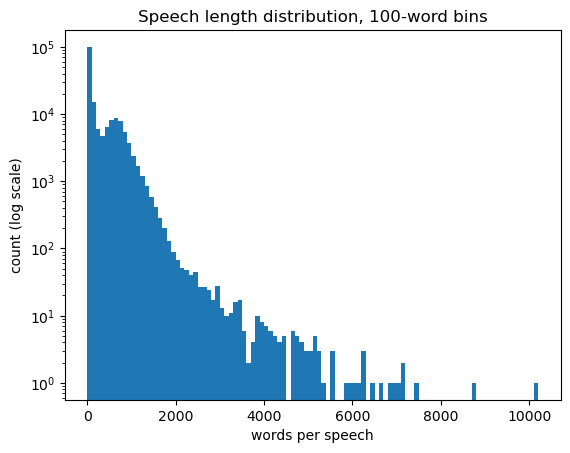

In [7]:
plt.hist(speeches["n_words"], bins=range(0, top + 100, 100))
plt.yscale("log")
plt.xlabel("words per speech"); plt.ylabel("count (log scale)")
plt.title("Speech length distribution, 100-word bins")
plt.show()

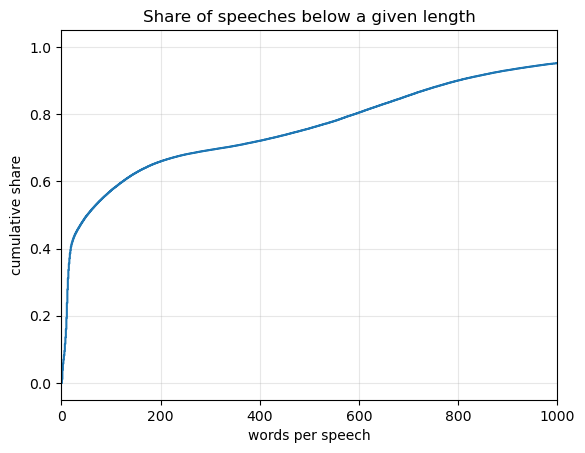

under   10 words: 16.0%
under   20 words: 40.5%
under   30 words: 44.7%
under   50 words: 49.5%
under  100 words: 57.2%
under  200 words: 65.9%
under  500 words: 75.7%


In [8]:
s = speeches["n_words"].sort_values()
cum = (s.rank(method="first") / len(s)).values

plt.plot(s.values, cum)
plt.xlim(0, 1000)
plt.xlabel("words per speech"); plt.ylabel("cumulative share")
plt.title("Share of speeches below a given length")
plt.grid(True, alpha=.3)
plt.show()

# And the exact numbers behind it:
for t in [10, 20, 30, 50, 100, 200, 500]:
    print(f"under {t:>4} words: {(speeches['n_words'] < t).mean():5.1%}")

In [9]:
# Rough preview only; real truncation depends on the model's tokenizer, chosen later
for limit in [256, 512]:
    approx_word_cap = int(limit / 1.6)
    share = (speeches["n_words"] > approx_word_cap).mean()
    print(f"~{limit} token model (~{approx_word_cap} words): {share:.1%} may be truncated")

~256 token model (~160 words): 36.6% may be truncated
~512 token model (~320 words): 30.2% may be truncated


*Possible decision*: Filter out speeches that are only 10 words long (approx. 16%)


*Note*: Depending on what encoder-only model we will choose maybe 30% of the speeches could be truncated

In [10]:
# Filter out short interjections or remarks
min_words = 10
speeches = speeches[speeches["n_words"] >= min_words].copy()

print(f"After length filter: {len(speeches)} speeches")

After length filter: 146223 speeches


*Possible decision*: Keep politician IDs as they are and use the factions IDs in the speeches dataset and factions dataset to match and create a new column with faction names

In [11]:
# Ignore unmatched factions (-1) so chairing and minsterial speeches
speeches = speeches[speeches["factionId"] != -1]
print(f"{len(speeches):,} speeches remain after dropping factionId -1")

75,865 speeches remain after dropping factionId -1


In [12]:
# factions.csv columns: id, abbreviation, full_name
# Rename so the key lines up with the speeches table
faction_names = factions.rename(columns={"id": "factionId", "abbreviation": "party"})

# Merge to attach the party name; factionId stays, `party` is the new column
speeches = speeches.merge(faction_names[["factionId", "party"]],
                          on="factionId", how="left")

print(speeches["party"].value_counts())

party
CDU/CSU         20959
SPD             16352
Grüne           14574
DIE LINKE.      11937
FDP              7721
AfD              4191
Fraktionslos      131
Name: count, dtype: int64


In [13]:
# An MP whose factionId changes over time has switched factions
faction_per_mp = speeches.groupby("politicianId")["factionId"].nunique()
switchers = faction_per_mp[faction_per_mp > 1].index

print(f"{len(switchers)} MPs appear under more than one faction (possible switchers)")

4 MPs appear under more than one faction (possible switchers)


**Unit of Analysis: MP-year**

*Possible decision*: MP-year is the primary unit because single speeches are too noisy (dominated by the day's topic), MP-month is sparse as most MPs dont speak enough per month and MP-year gives enought text per cell for a stable average.

In [14]:
speeches["year"] = speeches["date"].dt.year
speeches["year_month"] = speeches["date"].dt.to_period("M").astype(str)

# How much text lands in each cell under each option?
per_mp_year  = speeches.groupby(["politicianId", "year"]).size()
per_mp_month = speeches.groupby(["politicianId", "year_month"]).size()

print(f"Median speeches per MP-year : {per_mp_year.median():.0f}")
print(f"Median speeches per MP-month: {per_mp_month.median():.0f}")
print(f"MP-months with fewer than 3 speeches: {(per_mp_month < 3).mean():.0%}")

Median speeches per MP-year : 8
Median speeches per MP-month: 2
MP-months with fewer than 3 speeches: 71%


In [15]:
# Define the events
events = pd.DataFrame([
    ("2010-05-01", "Eurozone / Greek debt crisis",  "crisis"),
    ("2015-09-01", "European migration crisis",      "crisis"),
    ("2017-09-24", "AfD enters Bundestag (election)", "election"),
    ("2020-03-22", "COVID-19 pandemic",              "crisis"),
], columns=["date", "label", "type"])

events["date"] = pd.to_datetime(events["date"])
events

,date,label,type
0,2010-05-01,Eurozone / Greek debt crisis,crisis
1,2015-09-01,European migration crisis,crisis
2,2017-09-24,AfD enters Bundestag (election),election
3,2020-03-22,COVID-19 pandemic,crisis


### Peek at CHES

In [16]:
# Peek at CHES
print(list(ches.columns))
ches.head()

['year', 'country', 'eastwest', 'eumember', 'party_id', 'party', 'cmp_id', 'vote', 'seat', 'electionyear', 'epvote', 'family', 'govt', 'lrgen', 'lrecon', 'lrecon_salience', 'lrecon_dissent', 'lrecon_blur', 'galtan', 'galtan_salience', 'galtan_dissent', 'galtan_blur', 'eu_position', 'eu_salience', 'eu_dissent', 'eu_blur', 'spendvtax', 'spendvtax_salience', 'deregulation', 'dereg_salience', 'redistribution', 'redist_salience', 'econ_interven', 'civlib_laworder', 'civlib_salience', 'sociallifestyle', 'social_salience', 'womens_rights', 'lgbtq_rights', 'samesex_marriage', 'religious_principles', 'relig_salience', 'immigrate_policy', 'immigrate_salience', 'immigrate_dissent', 'multiculturalism', 'multicult_salience', 'multicult_dissent', 'nationalism', 'nationalism_salience', 'ethnic_minorities', 'ethnic_salience', 'urban_rural', 'urban_salience', 'environment', 'enviro_salience', 'climate_change', 'climate_change_salience', 'protectionism', 'regions', 'region_salience', 'international_secu

,year,country,eastwest,eumember,party_id,party,cmp_id,vote,seat,electionyear,...,people_vs_elite,antielite_salience,corrupt_salience,members_vs_leadership,executive_power,judicial_independence,mip_one,mip_two,mip_three,chesversion
0,1999,1,1,1,104,ECOLO,21111.0,7.3,7.3,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
1,1999,1,1,1,112,VB,21914.0,9.9,10.0,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
2,1999,1,1,1,111,FDF,21912.0,2.4,3.0,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
3,1999,1,1,1,110,VU,21913.0,5.6,5.3,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
4,1999,1,1,1,105,AGALEV,21112.0,7.0,6.0,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1


In [17]:
# Filter CHES to Germany
ches_de = ches[ches["country"] == 3].copy()

print(f"CHES Germany rows: {len(ches_de)}")
print("Years available:", sorted(ches_de["year"].unique()))
print()

# The columns we care about: party identity + the cmp_id bridge + ideology scores
cols = ["year", "party_id", "party", "cmp_id", "lrgen", "lrecon", "galtan"]
cols = [c for c in cols if c in ches_de.columns]
ches_de[cols].sort_values(["party", "year"])

CHES Germany rows: 54
Years available: [np.int64(1999), np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2019), np.int64(2024)]



,year,party_id,party,cmp_id,lrgen,lrecon,galtan
183,2014,310,AfD,41953.0,8.923077,8.333333,8.692307
189,2019,310,AfD,41953.0,9.238095,7.000000,9.523809
204,2024,310,AfD,41953.0,9.263158,7.631579,9.388889
199,2024,313,BSW,NaN,3.625000,2.777778,7.062500
151,1999,301,CDU,41521.0,5.866667,5.666667,6.333333
161,2002,301,CDU,41521.0,5.930000,5.860000,6.640000
165,2006,301,CDU,41521.0,6.360000,6.820000,6.910000
175,2010,301,CDU,41521.0,6.125000,6.000000,6.250000
182,2014,301,CDU,41521.0,5.923077,5.916667,6.000000
191,2019,301,CDU,41521.0,5.857143,5.904762,5.857143


### Peek at Manifesto

In [18]:
print(list(manifesto.columns)[:30])
manifesto.head()

['country', 'countryname', 'oecdmember', 'eumember', 'edate', 'date', 'party', 'partyname', 'partyabbrev', 'parfam', 'candidatename', 'coderid', 'manual', 'coderyear', 'testresult', 'testeditsim', 'pervote', 'voteest', 'presvote', 'absseat', 'totseats', 'progtype', 'datasetorigin', 'corpusversion', 'total', 'peruncod', 'per101', 'per102', 'per103', 'per104']


,country,countryname,oecdmember,eumember,edate,date,party,partyname,partyabbrev,parfam,...,per608_3,per703_1,per703_2,rile,planeco,markeco,welfare,intpeace,datasetversion,id_perm
0,11,Sweden,0,0,17/09/1944,194409,11220,Communist Party of Sweden,SKP,20,...,NaN,NaN,NaN,9.60,1.9,1.900,0.0,1.900,2025a,JN1LZH
1,11,Sweden,0,0,17/09/1944,194409,11320,Social Democratic Labour Party,SAP,30,...,NaN,NaN,NaN,-37.80,3.3,2.200,33.4,5.600,2025a,CMR7F6
2,11,Sweden,0,0,17/09/1944,194409,11420,People’s Party,FP,40,...,NaN,NaN,NaN,9.50,3.2,6.400,14.3,1.600,2025a,Z6OL6C
3,11,Sweden,0,0,17/09/1944,194409,11620,Right Party,NaN,60,...,NaN,NaN,NaN,28.00,1.8,22.800,10.6,0.000,2025a,YMKVN2
4,11,Sweden,0,0,17/09/1944,194409,11810,Agrarian Party,NaN,80,...,NaN,NaN,NaN,23.81,0.0,19.048,0.0,4.762,2025a,U4SCRD


In [19]:
# Two ways to isolate Germany — use whichever column you have
if "country" in manifesto.columns:
    mani_de = manifesto[manifesto["country"] == 41].copy()
else:
    mani_de = manifesto[manifesto["countryname"] == "Germany"].copy()

print(f"Manifesto Germany rows: {len(mani_de)}")

cols = ["party", "partyname", "date", "edate", "rile"]
cols = [c for c in cols if c in mani_de.columns]
mani_de[cols].sort_values("date").tail(20)

Manifesto Germany rows: 104


,party,partyname,date,edate,rile
2064,41223,The Left,201709,24/09/2017,-41.914
2065,41320,Social Democratic Party of Germany,201709,24/09/2017,-21.453
2066,41420,Free Democratic Party,201709,24/09/2017,0.578
2067,41521,Christian Democratic Union/Christian Social Union,201709,24/09/2017,2.757
2068,41953,Alternative for Germany,201709,24/09/2017,17.430
2075,41953,Alternative for Germany,202109,26/09/2021,26.048
2074,41912,South Schleswig Voters’ Union,202109,26/09/2021,-22.450
2073,41521,Christian Democratic Union/Christian Social Union,202109,26/09/2021,3.495
2071,41320,Social Democratic Party of Germany,202109,26/09/2021,-24.673
2070,41223,The Left,202109,26/09/2021,-36.167


In [20]:
# Save the preprocessed dataset
cols = ["id", "speechContent", "politicianId", "firstName", "lastName", "positionShort", "factionId", 
        "party", "date", "year", "year_month", "n_words"]
cols = [c for c in cols if c in speeches.columns]

speeches[cols].to_csv(PROCESSED / "speeches_preprocessed.csv.zip",
                      index=False, compression="zip")